In [1]:
import os
import pandas as pd
from lib.uncertinay_rat import SimulateRat
from prettytable import PrettyTable
import matplotlib.pyplot as plt
import pandas as pd

/Users/felix/MSE/03_projects/MT/zz_code/04_experiments/03_analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
EXPERIMENTS = '../02_data/2026-02-12/fever/gemma3'

In [3]:
def get_retrieval_success(row):
    return row['correct_paragraph']

def set_abstain(row):
    return (row['generated_answer'] == 'I DO NOT KNOW') or (row['generated_answer'] == 'NOT ENOUGH INFO')

def set_task_success(row):
    return row['correct_answer']

def set_generator_success(row):
    if row['retriever_success'] == True:
        return row['task_success']
    else:
        return row['abstain']

In [4]:
results_all = {}

for experiment in os.listdir(EXPERIMENTS):
    try:
        if experiment == '.DS_Store':
            continue
        id = experiment.split('_')

        results = pd.read_json(f'{EXPERIMENTS}/{experiment}/results.json')

        results['date'] = id[0]
        results['time'] = id[1]
        results['dataset'] = id[2]

        results['retriever_success'] = results.apply(get_retrieval_success, axis=1)
        results['abstain'] = results.apply(set_abstain, axis=1)
        results['task_success'] = results.apply(set_task_success, axis=1)
        results['generator_success'] = results.apply(set_generator_success, axis=1)

        results['retriever_strategy'] = id[3]

        results_all[experiment] = results
    except:
        continue

In [6]:
simulate = SimulateRat()

success_rates = {}
for experiment, results in results_all.items():
    success_rates[experiment], _ = simulate.compute_uncertainty(results)

In [7]:
t = PrettyTable(field_names=['Dataset', 'Retriever', 'P(R=1)', 'P(A=1)', 'P(T=1)'])

for experiment, success_rate in success_rates.items():
    id = experiment.split('_')
    t.add_row([
        id[2],
        id[3],
        f"{success_rate['r']['mean']:.2%} ± {success_rate['r']['std']:.4%}",
        f"{success_rate['a']['mean']:.2%} ± {success_rate['a']['std']:.4%}",
        f"{success_rate['t']['mean']:.2%} ± {success_rate['t']['std']:.4%}",
    ]) 

t

Dataset,Retriever,P(R=1),P(A=1),P(T=1)
fever-precomputed,probabilistic-hybrid-10,99.99% ± 0.0099%,4.13% ± 0.2006%,91.93% ± 0.2732%
fever-precomputed,probabilistic-sparse-7,69.42% ± 0.4601%,14.50% ± 0.3521%,81.37% ± 0.3894%
fever-precomputed,sparse,48.55% ± 0.5000%,22.05% ± 0.4156%,74.37% ± 0.4373%
fever-precomputed,probabilistic-dense-8,79.78% ± 0.4004%,10.09% ± 0.3008%,85.85% ± 0.3485%
fever-precomputed,probabilistic-dense-9,90.05% ± 0.2978%,7.03% ± 0.2553%,89.07% ± 0.3119%
fever-precomputed,probabilistic-dense-10,99.99% ± 0.0099%,4.12% ± 0.2003%,91.92% ± 0.2734%
fever-precomputed,probabilistic-sparse-1,10.01% ± 0.3004%,35.20% ± 0.4785%,60.65% ± 0.4873%
fever-precomputed,dense,64.53% ± 0.4780%,17.99% ± 0.3846%,78.34% ± 0.4125%
fever-precomputed,probabilistic-dense-1,10.20% ± 0.3030%,31.61% ± 0.4659%,64.28% ± 0.4780%
fever-precomputed,probabilistic-sparse-0,0.01% ± 0.0099%,38.42% ± 0.4879%,57.30% ± 0.4923%


In [8]:
data = {
    "name": [],
    "retriever": [],
    "retriever_mean": [],
    "retriever_std": [],
    "task_mean": [],
    "task_std": [],
}
for experiment, success_rate in success_rates.items():
    id = experiment.split('_')

    data['name'].append(id)
    data['retriever'].append(id[3])
    data['retriever_mean'].append(success_rate['r']['mean'])
    data['retriever_std'].append(success_rate['r']['std'])
    data['task_mean'].append(success_rate['t']['mean'])
    data['task_std'].append(success_rate['t']['std'])


In [9]:
df = pd.DataFrame(data)
df.sort_values(by='retriever_mean')
df['retriever_base'] = df['retriever'].apply(lambda r: r.split('-')[1] if r.startswith('probabilistic') else None)

In [10]:
def get_probs(df, type):
    df_p = df.loc[df['retriever_base'] == type]
    df_p = df_p.loc[df_p['retriever'].str.startswith('probabilistic')].sort_values(by='retriever_mean')

    return df_p

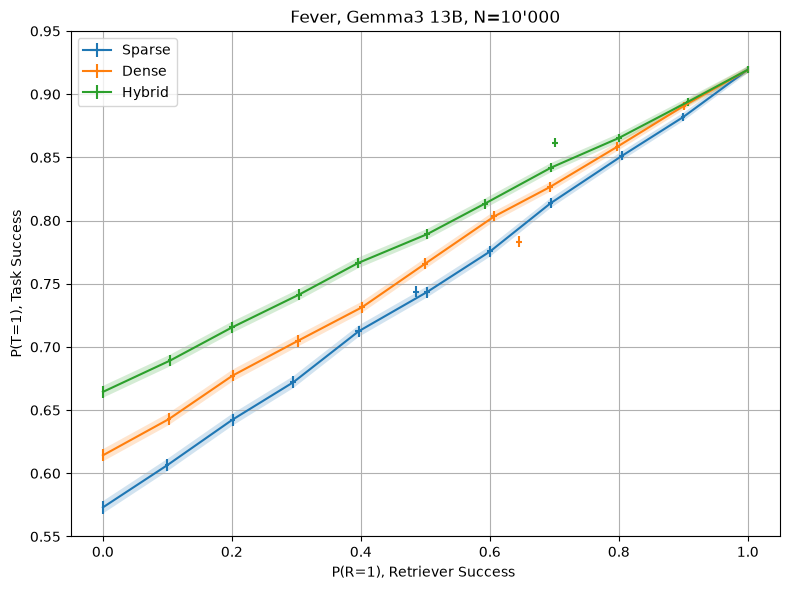

In [11]:
def plot_probs(df, axs, type):
    df_p = get_probs(df, type)
    axs.errorbar(
        df_p["retriever_mean"],
        df_p["task_mean"],
        xerr=df_p["retriever_std"],
        yerr=df_p["task_std"]
    )
    x = df_p["retriever_mean"]
    y = df_p["task_mean"]
    error = df_p["task_std"]
    axs.fill_between(x, y-error, y+error, alpha=0.2)

    df = df.loc[df['retriever'] == type]
    axs.errorbar(
        df["retriever_mean"],
        df["task_mean"],
        xerr=df["retriever_std"],
        yerr=df["task_std"],
        label=type.capitalize(),
        color=plt.gca().lines[-1].get_color()
    )


fig, axs = plt.subplots(1, 1, figsize=(8, 6))


plot_probs(df, axs, 'sparse')
plot_probs(df, axs, 'dense')
plot_probs(df, axs, 'hybrid')


plt.xlabel("P(R=1), Retriever Success ")
plt.ylabel("P(T=1), Task Success")

plt.title("Fever, Gemma3 13B, N=10'000")

plt.xlim(-0.05,1.05)
plt.ylim(0.55,0.95)

plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()
